------------------------------
PROJECT NAME: **FLOOD RISK CLASSIFIER**
-----------------------------

In [2431]:
#IMPORTED REQUIRED LIBRARIES
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import warnings 
warnings.filterwarnings('ignore')

In [2146]:
df1=pd.read_csv('flood_risk_dataset_india.csv')
df1                           

,Latitude,Longitude,Rainfall (mm),Temperature (°C),Humidity (%),River Discharge (m³/s),Water Level (m),Elevation (m),Land Cover,Soil Type,Population Density,Infrastructure,Historical Floods,Flood Occurred
0,18.861663,78.835584,218.999493,34.144337,43.912963,4236.182888,7.415552,377.465433,Water Body,Clay,7276.742184,1,0,1
1,35.570715,77.654451,55.353599,28.778774,27.585422,2472.585219,8.811019,7330.608875,Forest,Peat,6897.736956,0,1,0
2,29.227824,73.108463,103.991908,43.934956,30.108738,977.328053,4.631799,2205.873488,Agricultural,Loam,4361.518494,1,1,1
3,25.361096,85.610733,198.984191,21.569354,34.453690,3683.208933,2.891787,2512.277800,Desert,Sandy,6163.069701,1,1,0
4,12.524541,81.822101,144.626803,32.635692,36.292267,2093.390678,3.188466,2001.818223,Agricultural,Loam,6167.964591,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,32.872024,93.434120,285.682635,37.621017,69.795616,4830.703665,5.943965,2850.197900,Agricultural,Clay,6943.559433,0,0,0
9996,34.027756,69.357605,224.347263,37.935808,38.095486,1866.199787,9.466158,3314.692947,Forest,Clay,3011.997459,1,0,0
9997,35.454530,76.807256,5.836759,23.087083,79.919607,1523.374305,9.209185,3377.296962,Desert,Clay,7149.938303,1,0,1
9998,19.527152,80.856280,120.301453,28.029593,61.680873,2036.812638,2.004644,1146.986151,Water Body,Sandy,906.031452,1,0,1


In [2147]:
flood_data=df1.copy()

In [2148]:
flood_data.columns

Index(['Latitude', 'Longitude', 'Rainfall (mm)', 'Temperature (°C)',
       'Humidity (%)', 'River Discharge (m³/s)', 'Water Level (m)',
       'Elevation (m)', 'Land Cover', 'Soil Type', 'Population Density',
       'Infrastructure', 'Historical Floods', 'Flood Occurred'],
      dtype='object')

In [2150]:
print(f"First Five Rows of Data:\n {flood_data.head(5)}")

First Five Rows of Data:
     Latitude  Longitude  Rainfall (mm)  Temperature (°C)  Humidity (%)  \
0  18.861663  78.835584     218.999493         34.144337     43.912963   
1  35.570715  77.654451      55.353599         28.778774     27.585422   
2  29.227824  73.108463     103.991908         43.934956     30.108738   
3  25.361096  85.610733     198.984191         21.569354     34.453690   
4  12.524541  81.822101     144.626803         32.635692     36.292267   

   River Discharge (m³/s)  Water Level (m)  Elevation (m)    Land Cover  \
0             4236.182888         7.415552     377.465433    Water Body   
1             2472.585219         8.811019    7330.608875        Forest   
2              977.328053         4.631799    2205.873488  Agricultural   
3             3683.208933         2.891787    2512.277800        Desert   
4             2093.390678         3.188466    2001.818223  Agricultural   

  Soil Type  Population Density  Infrastructure  Historical Floods  \
0      C

In [2151]:
print(f"Last Five Rows of Data:\n {flood_data.tail(5)}")

Last Five Rows of Data:
        Latitude  Longitude  Rainfall (mm)  Temperature (°C)  Humidity (%)  \
9995  32.872024  93.434120     285.682635         37.621017     69.795616   
9996  34.027756  69.357605     224.347263         37.935808     38.095486   
9997  35.454530  76.807256       5.836759         23.087083     79.919607   
9998  19.527152  80.856280     120.301453         28.029593     61.680873   
9999  14.297072  72.995680      77.219394         29.622711     88.936537   

      River Discharge (m³/s)  Water Level (m)  Elevation (m)    Land Cover  \
9995             4830.703665         5.943965    2850.197900  Agricultural   
9996             1866.199787         9.466158    3314.692947        Forest   
9997             1523.374305         9.209185    3377.296962        Desert   
9998             2036.812638         2.004644    1146.986151    Water Body   
9999             2614.166967         0.991856    8381.595028        Desert   

     Soil Type  Population Density  Infrast

In [2157]:
print(f"Total Null values per Column:\n{flood_data.isna().sum()}")

Total Null values per Column:
Latitude                  0
Longitude                 0
Rainfall (mm)             0
Temperature (°C)          0
Humidity (%)              0
River Discharge (m³/s)    0
Water Level (m)           0
Elevation (m)             0
Land Cover                0
Soil Type                 0
Population Density        0
Infrastructure            0
Historical Floods         0
Flood Occurred            0
dtype: int64


In [2159]:
flood_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Latitude                10000 non-null  float64
 1   Longitude               10000 non-null  float64
 2   Rainfall (mm)           10000 non-null  float64
 3   Temperature (°C)        10000 non-null  float64
 4   Humidity (%)            10000 non-null  float64
 5   River Discharge (m³/s)  10000 non-null  float64
 6   Water Level (m)         10000 non-null  float64
 7   Elevation (m)           10000 non-null  float64
 8   Land Cover              10000 non-null  object 
 9   Soil Type               10000 non-null  object 
 10  Population Density      10000 non-null  float64
 11  Infrastructure          10000 non-null  int64  
 12  Historical Floods       10000 non-null  int64  
 13  Flood Occurred          10000 non-null  int64  
dtypes: float64(9), int64(3), object(2)
memo

In [2161]:
print(f"The statistical Summary of Flood dataset is:\n {flood_data.describe()}")

The statistical Summary of Flood dataset is:
            Latitude     Longitude  Rainfall (mm)  Temperature (°C)  \
count  10000.000000  10000.000000   10000.000000      10000.000000   
mean      22.330627     82.631366     150.015118         29.961401   
std        8.341274      8.389542      86.032127          8.669838   
min        8.000337     68.004575       0.014437         15.000166   
25%       15.143537     75.364428      76.124373         22.405717   
50%       22.283330     82.671007     150.620428         30.000907   
75%       29.460184     89.937897     223.402156         37.413488   
max       36.991813     96.997820     299.970293         44.993681   

       Humidity (%)  River Discharge (m³/s)  Water Level (m)  Elevation (m)  \
count  10000.000000            10000.000000     10000.000000   10000.000000   
mean      59.749104             2515.722946         5.017881    4417.138177   
std       23.142734             1441.706442         2.876579    2530.245421   
min    

**ANALYSIS**
----------------

In [2164]:
displt=flood_data[['Latitude', 'Longitude', 'Rainfall (mm)', 'Temperature (°C)',
       'Humidity (%)', 'River Discharge (m³/s)', 'Water Level (m)',
       'Elevation (m)', 'Population Density',
       'Infrastructure', 'Historical Floods', 'Flood Occurred']]

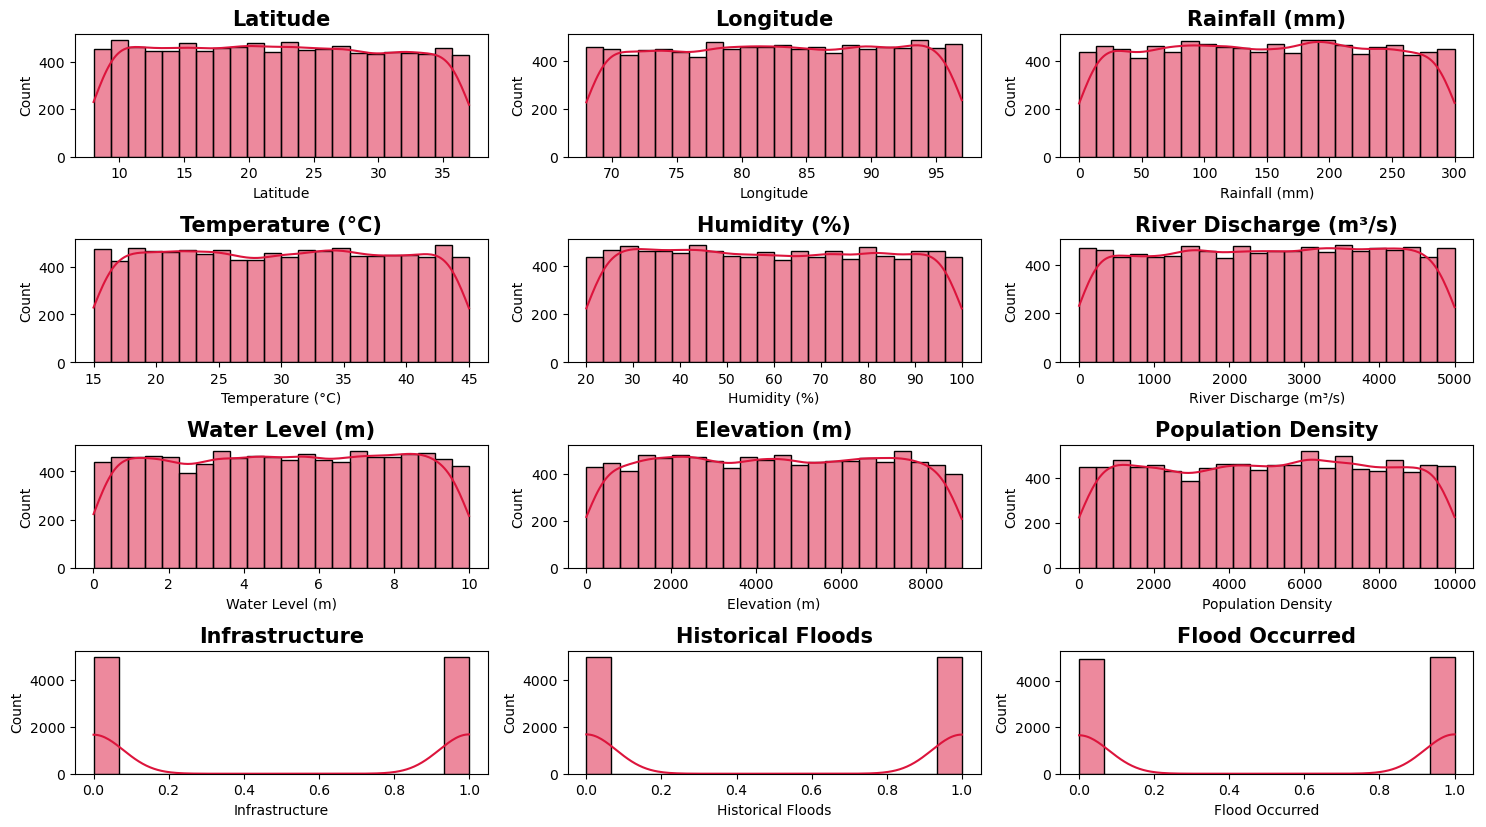

In [2165]:
#for data skewness through histplot
plt.figure(figsize=(15,10))
for i in range(len(displt.columns)):
  plt.subplot(5,3,i+1)
  sns.histplot(displt[displt.columns[i]],color='crimson',kde=True)
  plt.title(displt.columns[i],fontweight='bold',fontsize=15)
plt.tight_layout()
plt.show()

In [2166]:
for i in displt:
    print(f'Total Skewness per data: {flood_data[i].skew()}')
#There is no Skewness in the entire data.

Total Skewness per data: 0.024879927051299943
Total Skewness per data: -0.018444774303176065
Total Skewness per data: -0.0019412941289528964
Total Skewness per data: 0.004288783104256137
Total Skewness per data: 0.0199336227992903
Total Skewness per data: -0.024095678771556026
Total Skewness per data: -0.01960948941773566
Total Skewness per data: 0.0008942079503231085
Total Skewness per data: -0.021914210772869723
Total Skewness per data: -0.00800126424041549
Total Skewness per data: 0.005200797728255887
Total Skewness per data: -0.022804902566347464


In [2167]:
for_box=flood_data[['Latitude', 'Longitude', 'Rainfall (mm)', 'Temperature (°C)',
       'Humidity (%)', 'River Discharge (m³/s)', 'Water Level (m)',
       'Elevation (m)', 'Population Density']]

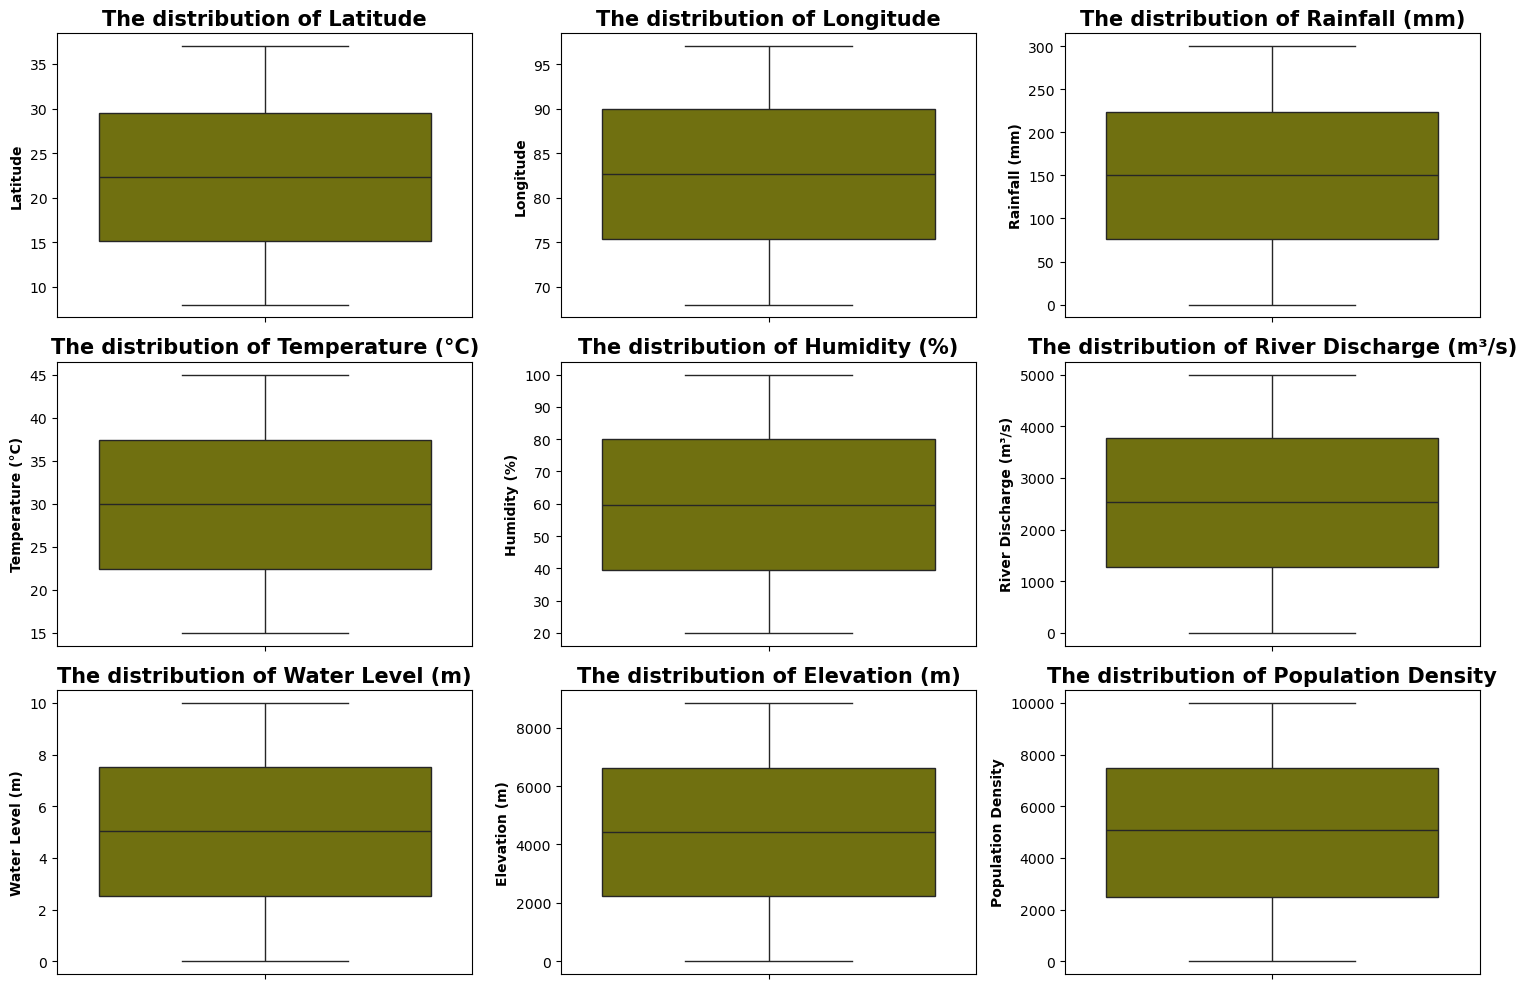

In [2168]:
#The boxplot to check the outliers as there is none in the dataset
plt.figure(figsize=(15,10))
for i in range(len(for_box.columns)):
    plt.subplot(3,3,i+1)
    sns.boxplot(for_box[for_box.columns[i]],color='olive')
    plt.title(f"The distribution of {for_box.columns[i]}",fontweight='bold',fontsize=15)
    plt.ylabel(for_box.columns[i],fontweight='bold')
plt.tight_layout()
plt.show()

In [2170]:
flood_data['Flood Occurred'].value_counts()

Flood Occurred
1    5057
0    4943
Name: count, dtype: int64

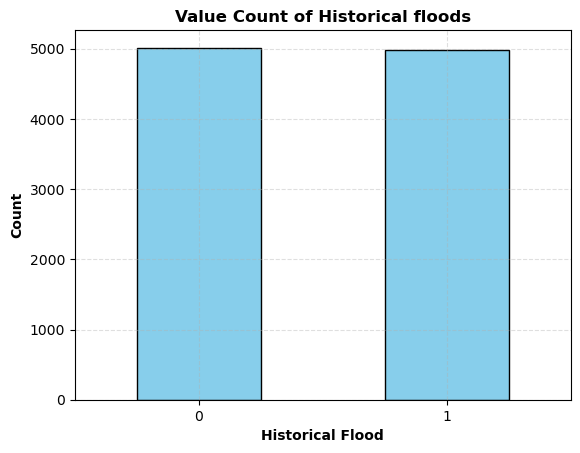

In [2171]:
# 
flood_data['Historical Floods'].value_counts().plot(kind='bar',color='skyblue',edgecolor='black')
plt.title("Value Count of Historical floods",fontweight='bold',fontsize=12)
plt.xlabel("Historical Flood",fontweight='bold')
plt.ylabel("Count",fontweight='bold')
plt.grid(linestyle='--',alpha=0.4)
plt.xticks(rotation=360)
plt.show()

In [2173]:
for i in flood_data:
    print(f"The Value Count of: {flood_data[i].value_counts()}")
    print('---------------------------------------------------')

The Value Count of: Latitude
18.861663    1
18.023184    1
29.647112    1
33.911789    1
29.946887    1
            ..
13.654281    1
33.821876    1
29.749356    1
34.338626    1
14.297072    1
Name: count, Length: 10000, dtype: int64
---------------------------------------------------
The Value Count of: Longitude
78.835584    1
85.034124    1
86.656405    1
74.653142    1
72.573889    1
            ..
93.027781    1
80.083432    1
89.572093    1
92.834849    1
72.995680    1
Name: count, Length: 10000, dtype: int64
---------------------------------------------------
The Value Count of: Rainfall (mm)
218.999493    1
2.201288      1
197.152952    1
125.685869    1
142.511313    1
             ..
153.063961    1
290.780773    1
286.709868    1
123.728847    1
77.219394     1
Name: count, Length: 10000, dtype: int64
---------------------------------------------------
The Value Count of: Temperature (°C)
34.144337    1
19.994720    1
32.083541    1
23.124871    1
27.152524    1
          

In [2174]:
flood_data['Soil Type'].unique()

array(['Clay', 'Peat', 'Loam', 'Sandy', 'Silt'], dtype=object)

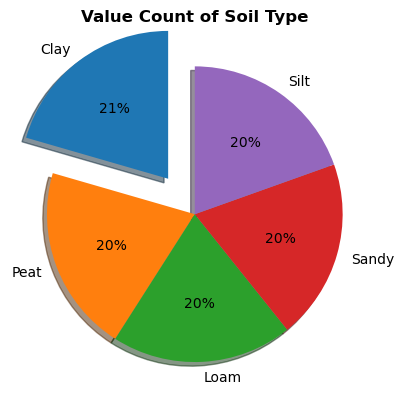

In [2178]:
#Value count of Soil type through Pie Chart.
labels=['Clay', 'Peat', 'Loam', 'Sandy', 'Silt']
plt.pie(flood_data['Soil Type'].value_counts(), autopct='%.0f%%',labels=labels,startangle=90,explode=[0.3,0,0,0,0],shadow=True)
plt.title("Value Count of Soil Type",fontweight='bold')
plt.show()

In [2186]:
#Highest Land cover wise temperature 
highest_temp=flood_data.loc[flood_data.groupby('Land Cover')['Temperature (°C)'].idxmax()].reset_index()
high_temp=highest_temp[['Land Cover','Temperature (°C)','Population Density']].sort_values(by='Population Density',ascending=False)

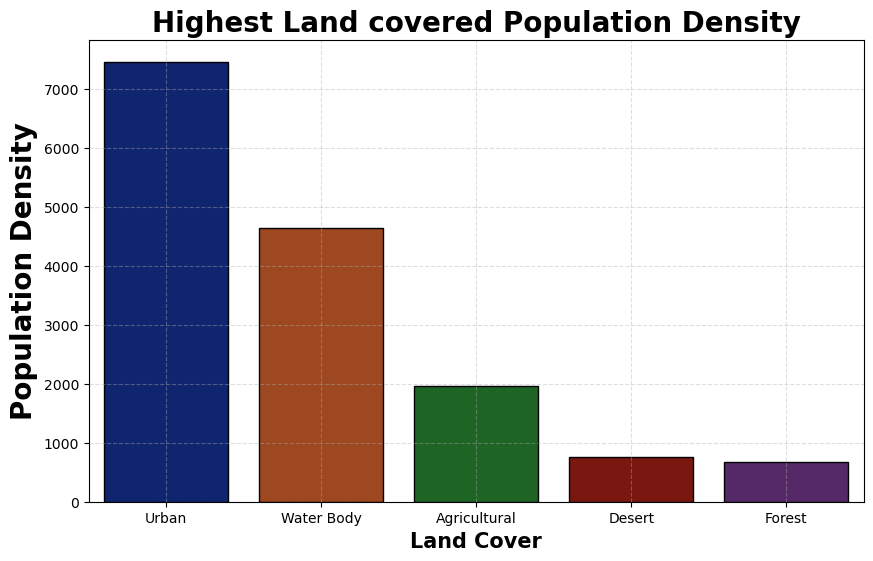

In [2188]:
plt.figure(figsize=(10,6))
sns.barplot(data=high_temp,x='Land Cover',y='Population Density',palette='dark',hue='Land Cover',edgecolor='black')
plt.title("Highest Land covered Population Density",fontweight='bold',fontsize=20)
plt.xlabel("Land Cover",fontweight='bold',fontsize=15)
plt.ylabel("Population Density",fontweight='bold',fontsize=20)
plt.grid(linestyle='--',alpha=0.4)
plt.show()

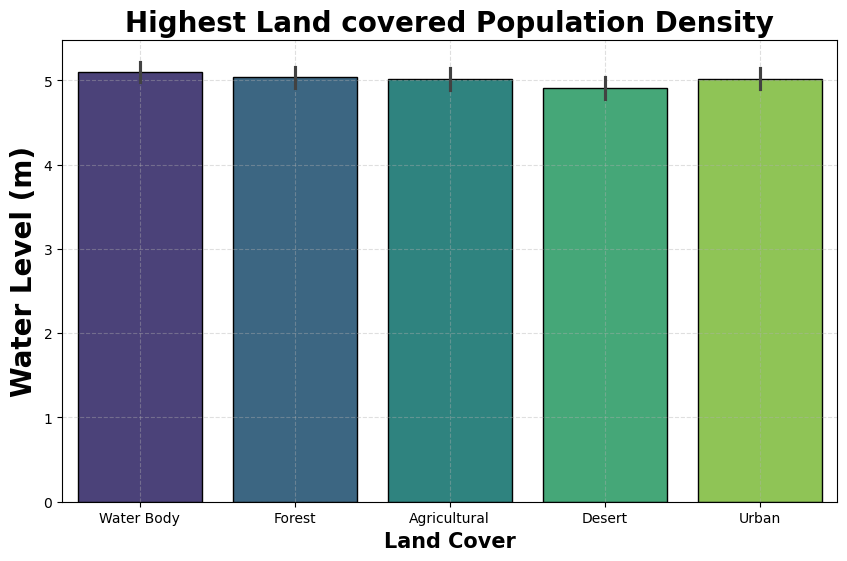

In [2355]:
plt.figure(figsize=(10,6))
sns.barplot(data=flood_data,x='Land Cover',y='Water Level (m)',palette='viridis',hue='Land Cover',edgecolor='black')
plt.title("Highest Land covered Population Density",fontweight='bold',fontsize=20)
plt.xlabel("Land Cover",fontweight='bold',fontsize=15)
plt.ylabel("Water Level (m)",fontweight='bold',fontsize=20)
plt.grid(linestyle='--',alpha=0.4)
plt.show()

In [2435]:
#Highest Land cover with the temperature in case of flood occurance. 
flood_occ=flood_data[flood_data['Flood Occurred']==1]
highest_land=flood_occ.loc[flood_occ.groupby('Land Cover')['Temperature (°C)'].idxmax()].reset_index()


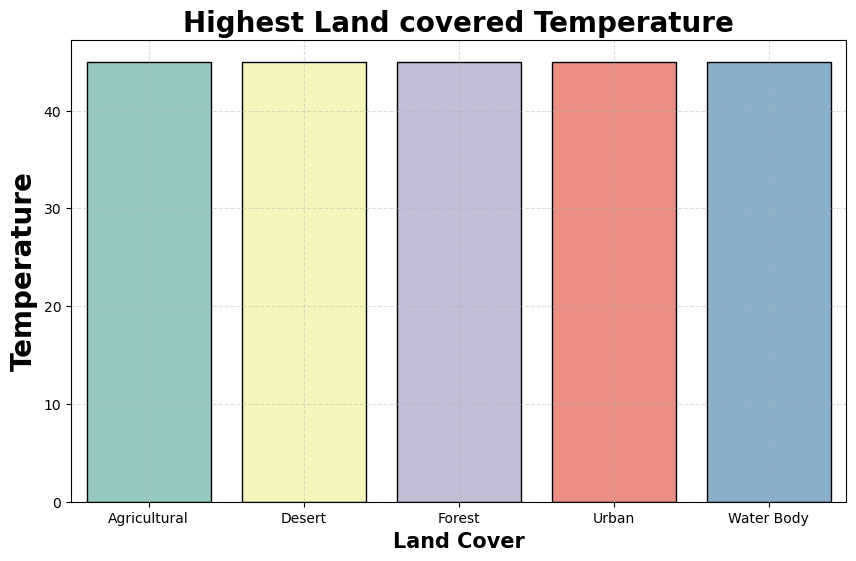

In [2192]:
plt.figure(figsize=(10,6))
sns.barplot(data=highest_land,x='Land Cover',y='Temperature (°C)',palette='Set3',hue='Land Cover',edgecolor='black')
plt.title("Highest Land covered Temperature",fontweight='bold',fontsize=20)
plt.xlabel("Land Cover",fontweight='bold',fontsize=15)
plt.ylabel("Temperature",fontweight='bold',fontsize=20)
plt.grid(linestyle='--',alpha=0.4)
plt.show()

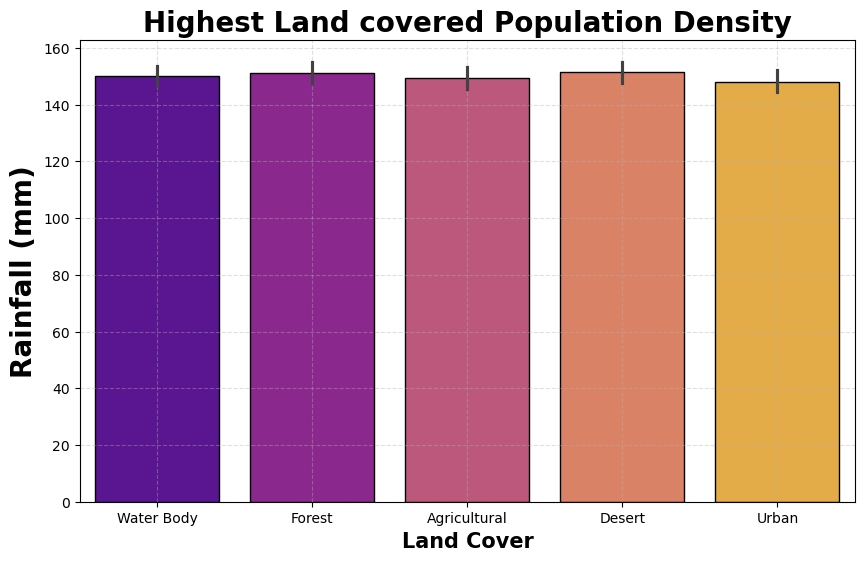

In [2194]:
plt.figure(figsize=(10,6))
sns.barplot(data=flood_data,x='Land Cover',y='Rainfall (mm)',palette='plasma',hue='Land Cover',edgecolor='black')
plt.title("Highest Land covered Population Density",fontweight='bold',fontsize=20)
plt.xlabel("Land Cover",fontweight='bold',fontsize=15)
plt.ylabel("Rainfall (mm)",fontweight='bold',fontsize=20)
plt.grid(linestyle='--',alpha=0.4)
plt.show()

In [2196]:
flood_data.sample()

,Latitude,Longitude,Rainfall (mm),Temperature (°C),Humidity (%),River Discharge (m³/s),Water Level (m),Elevation (m),Land Cover,Soil Type,Population Density,Infrastructure,Historical Floods,Flood Occurred
6904,15.612798,87.784565,99.431421,44.179335,69.677911,1018.378079,3.184744,4469.990044,Forest,Loam,1266.18565,0,1,1


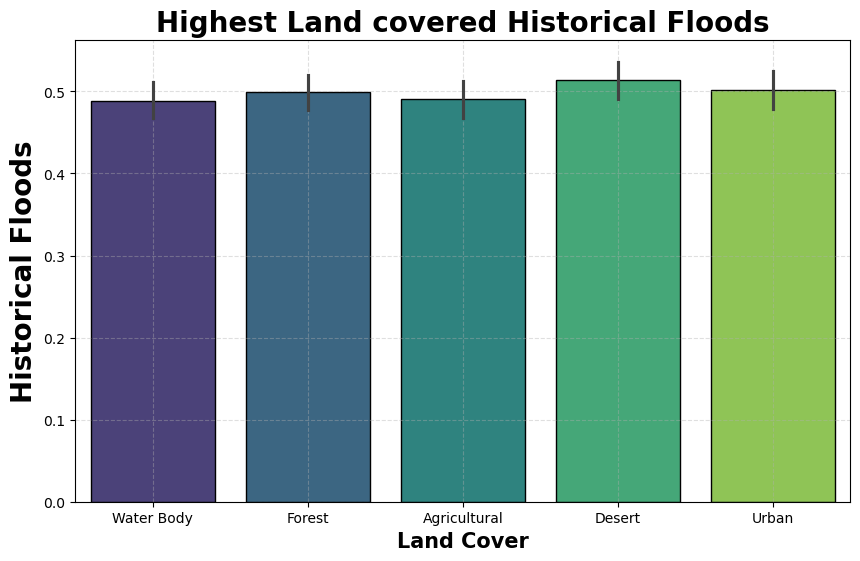

In [2357]:
plt.figure(figsize=(10,6))
sns.barplot(data=flood_data,x='Land Cover',y='Historical Floods',palette='viridis',hue='Land Cover',edgecolor='black')
plt.title("Highest Land covered Historical Floods",fontweight='bold',fontsize=20)
plt.xlabel("Land Cover",fontweight='bold',fontsize=15)
plt.ylabel("Historical Floods",fontweight='bold',fontsize=20)
plt.grid(linestyle='--',alpha=0.4)
plt.show()

In [2200]:
labels=flood_data['Land Cover'].unique()

In [2437]:
#in case of flood not occured highest temperature. 
flood_occ=flood_data[flood_data['Flood Occurred']==0]
flood_occured=flood_occ.loc[flood_occ.groupby('Land Cover')['Temperature (°C)'].idxmax()].reset_index()[['Land Cover','Temperature (°C)']]
flood_occured

,Land Cover,Temperature (°C)
0,Agricultural,44.978061
1,Desert,44.947042
2,Forest,44.953387
3,Urban,44.990916
4,Water Body,44.964490


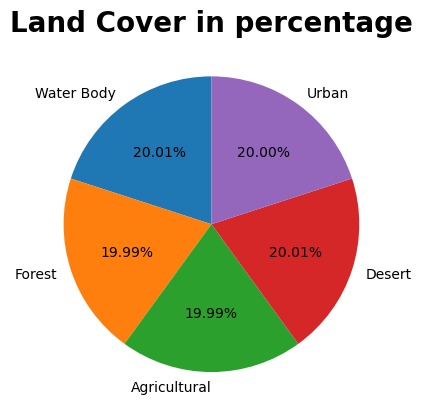

In [2204]:
plt.pie(data=flood_occured,x='Temperature (°C)', labels=labels,autopct='%.2f%%',startangle=90)
plt.title("Land Cover in percentage",fontweight='bold',fontsize=20)
plt.show()

In [2206]:
#Highest Rainfall per Latitude location.
lat_rainfall=flood_data.groupby('Latitude')['Rainfall (mm)'].max().sort_values(ascending=False).reset_index()
lat_rainfall

,Latitude,Rainfall (mm)
0,26.150850,299.970293
1,24.406795,299.919625
2,26.959560,299.908683
3,29.694122,299.896893
4,32.840588,299.879515
...,...,...
9995,29.829087,0.072265
9996,23.022445,0.058459
9997,31.763408,0.037542
9998,26.178154,0.033070


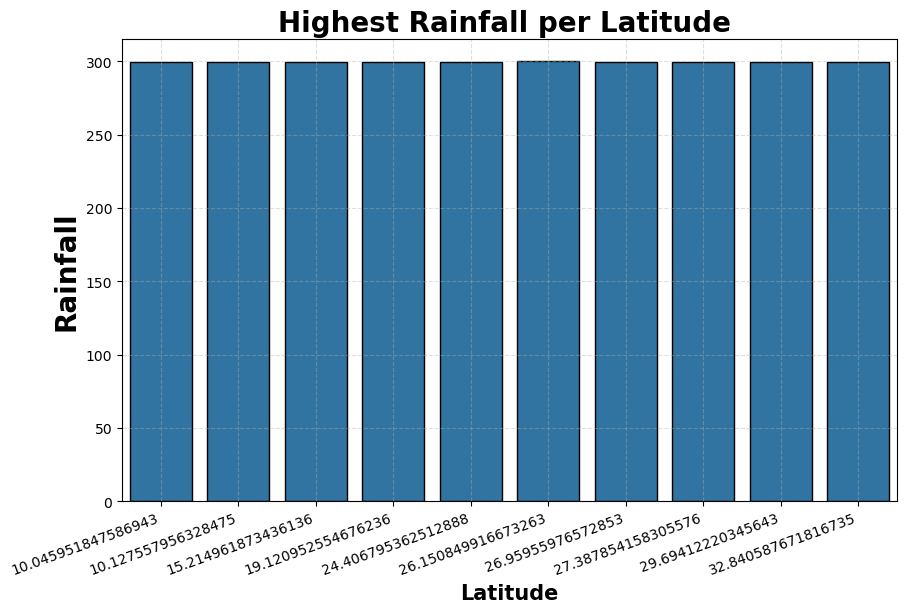

In [2212]:
plt.figure(figsize=(10,6))
sns.barplot(data=lat_rainfall.head(10),x='Latitude',y='Rainfall (mm)',edgecolor='black')
plt.title("Highest Rainfall per Latitude ",fontweight='bold',fontsize=20)
plt.xlabel("Latitude",fontweight='bold',fontsize=15)
plt.ylabel("Rainfall",fontweight='bold',fontsize=20)
plt.grid(linestyle='--',alpha=0.4)
plt.xticks(rotation=20,ha='right')
plt.show()

In [1706]:
flood_data.sample()

,Latitude,Longitude,Rainfall (mm),Temperature (°C),Humidity (%),River Discharge (m³/s),Water Level (m),Elevation (m),Land Cover,Soil Type,Population Density,Infrastructure,Historical Floods,Flood Occurred
4589,29.149984,70.60128,250.456047,20.960825,45.919123,1919.715098,9.569609,4112.54956,Agricultural,Sandy,2200.583649,0,0,1


In [1696]:
flood_data['Land Cover'].value_counts('Count')

Land Cover
Water Body      0.2046
Desert          0.2033
Forest          0.2005
Agricultural    0.1978
Urban           0.1938
Name: proportion, dtype: float64

In [1198]:
#in case of NO FLOOD highest rainfall mm in various Land cover.
f=flood_data[flood_data['Flood Occurred']==0]
rainfall=f.loc[f.groupby(['Land Cover','Land Cover'])['Rainfall (mm)'].idxmax()].reset_index()[['Land Cover','Rainfall (mm)']]
rainfall

,Land Cover,Rainfall (mm)
0,Agricultural,299.908683
1,Desert,299.387015
2,Forest,299.919625
3,Urban,299.596176
4,Water Body,299.515464


In [1715]:
#average Rainfall in case of flood occurence.
flood_yes=flood_data[flood_data['Flood Occurred']==1]
latitude1=flood_yes.groupby(['Latitude','Land Cover'])['Rainfall (mm)'].mean().sort_values(ascending=False).reset_index()
latitude1

,Latitude,Land Cover,Rainfall (mm)
0,26.150850,Desert,299.970293
1,32.840588,Agricultural,299.879515
2,15.214962,Urban,299.835157
3,27.387854,Agricultural,299.823176
4,18.250847,Forest,299.680121
...,...,...,...
5052,30.965290,Water Body,0.103310
5053,10.253660,Agricultural,0.073587
5054,29.829087,Water Body,0.072265
5055,31.763408,Urban,0.037542


In [1717]:
latitude1.columns

Index(['Latitude', 'Land Cover', 'Rainfall (mm)'], dtype='object')

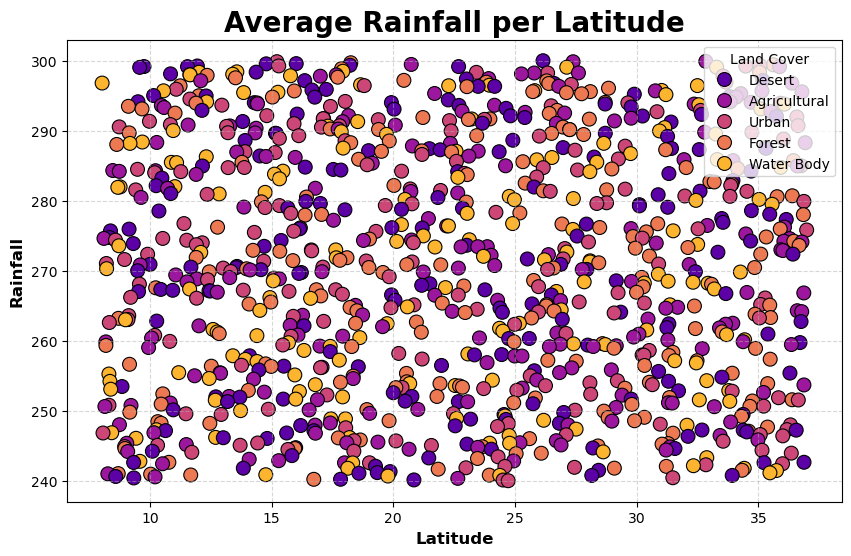

In [2214]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=latitude1.head(1000),x='Latitude',y='Rainfall (mm)',hue='Land Cover', marker='o', palette='plasma',s=100,edgecolor='black')
plt.title("Average Rainfall per Latitude",fontsize=20,fontweight='bold')
plt.xlabel("Latitude",fontsize=12,fontweight='bold')
plt.ylabel("Rainfall",fontsize=12,fontweight='bold')
plt.grid(linestyle='--',alpha=0.5)
plt.show()

In [1220]:
flood_data[flood_data['Land Cover']=='Urban'].value_counts().reset_index()

,Latitude,Longitude,Rainfall (mm),Temperature (°C),Humidity (%),River Discharge (m³/s),Water Level (m),Elevation (m),Land Cover,Soil Type,Population Density,Infrastructure,Historical Floods,Flood Occurred,count
0,8.000891,93.313325,72.859395,20.040622,41.645434,407.158839,8.534745,8271.629277,Urban,Clay,9856.869923,0,1,1,1
1,26.309903,93.303095,221.348198,27.934010,91.767261,4409.691229,8.927039,7188.871603,Urban,Loam,3431.213943,0,0,1,1
2,26.776767,78.893813,59.598191,39.431493,61.768117,762.938765,8.151058,8614.521329,Urban,Loam,7970.694135,0,0,0,1
3,26.731909,94.208023,111.983583,25.692213,48.868357,2785.125704,8.690660,6143.060064,Urban,Peat,5364.471456,1,1,0,1
4,26.711892,89.221389,279.641045,27.067527,62.068574,791.312373,6.736355,7192.179244,Urban,Sandy,8859.275641,1,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1933,17.150462,93.119479,189.935687,40.963670,54.217109,3923.556893,7.662835,5792.515698,Urban,Silt,109.518044,1,0,0,1
1934,17.145549,79.036702,181.627514,25.416803,24.372247,4346.127778,9.094188,1578.353078,Urban,Silt,4413.646356,1,1,0,1
1935,17.143420,90.484157,72.411191,34.009162,54.466352,193.639684,2.847078,2444.596205,Urban,Sandy,9483.939523,1,1,1,1
1936,17.141944,78.067838,24.432260,24.879480,25.422587,61.423359,0.678532,7041.464191,Urban,Peat,9274.073236,0,1,0,1


In [2222]:
#in case of flood and Land cover of Urban areas average Rainfall.
flood_yes=flood_data[(flood_data['Flood Occurred']==1) & (flood_data['Land Cover']=='Urban')]
latitude=flood_yes.groupby(['Latitude','Land Cover'])['Rainfall (mm)'].max().sort_values(ascending=False).reset_index()
latitude

,Latitude,Land Cover,Rainfall (mm)
0,15.214962,Urban,299.835157
1,35.068981,Urban,299.271414
2,15.291474,Urban,299.227914
3,34.483976,Urban,299.203365
4,23.412193,Urban,298.310693
...,...,...,...
994,12.563977,Urban,0.880217
995,27.179748,Urban,0.818623
996,33.635936,Urban,0.617106
997,31.763408,Urban,0.037542


<Figure size 1000x600 with 0 Axes>

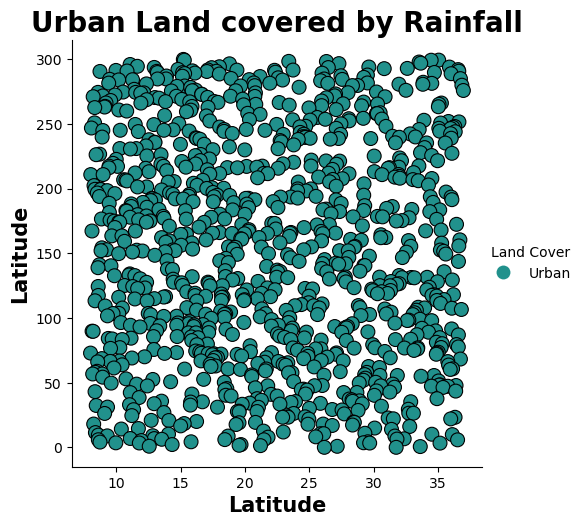

In [2224]:
plt.figure(figsize=(10,6))
sns.relplot(data=latitude,x='Latitude',y='Rainfall (mm)',hue='Land Cover', marker='o', palette='viridis',kind='scatter',s=100,edgecolor='black')
plt.title("Urban Land covered by Rainfall",fontsize=20,fontweight='bold')
plt.xlabel("Latitude",fontsize=15,fontweight='bold')
plt.ylabel("Latitude",fontsize=15,fontweight='bold')
plt.show()


<Figure size 1000x600 with 0 Axes>

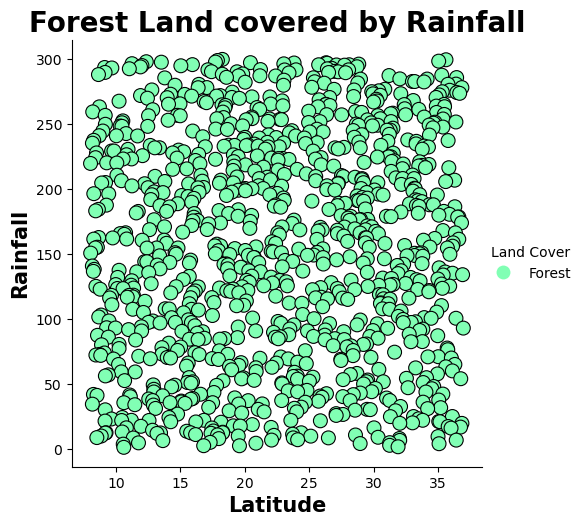

In [2226]:
#in case of food and Land cover of f areas average Rainfall.
flood_yes=flood_data[(flood_data['Flood Occurred']==1) & (flood_data['Land Cover']=='Forest')]
latitude=flood_yes.groupby(['Latitude','Land Cover'])['Rainfall (mm)'].max().sort_values(ascending=False).reset_index()
plt.figure(figsize=(10,6))
sns.relplot(data=latitude,x='Latitude',y='Rainfall (mm)',hue='Land Cover', marker='o', palette='rainbow',kind='scatter',s=100,edgecolor='black')
plt.title("Forest Land covered by Rainfall",fontsize=20,fontweight='bold')
plt.xlabel("Latitude",fontsize=15,fontweight='bold')
plt.ylabel("Rainfall",fontsize=15,fontweight='bold')
plt.show()

<Figure size 1000x600 with 0 Axes>

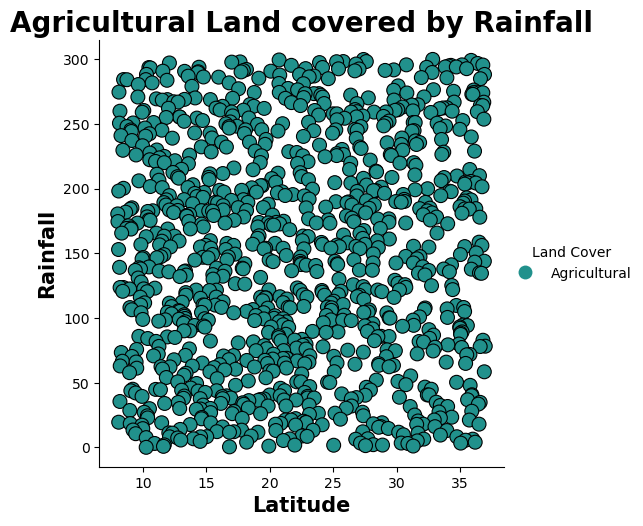

In [2228]:
#in case of food and Land cover of forest areas average Rainfall.
flood_yes=flood_data[(flood_data['Flood Occurred']==1) & (flood_data['Land Cover']=='Agricultural')]
latitude=flood_yes.groupby(['Latitude','Land Cover'])['Rainfall (mm)'].max().sort_values(ascending=False).reset_index()
plt.figure(figsize=(10,6))
sns.relplot(data=latitude,x='Latitude',y='Rainfall (mm)',hue='Land Cover', marker='o', palette='viridis',kind='scatter',s=100,edgecolor='black')
plt.title("Agricultural Land covered by Rainfall",fontsize=20,fontweight='bold')
plt.xlabel("Latitude",fontsize=15,fontweight='bold')
plt.ylabel("Rainfall",fontsize=15,fontweight='bold')
plt.show()

In [1743]:
flood_data.columns

Index(['Latitude', 'Longitude', 'Rainfall (mm)', 'Temperature (°C)',
       'Humidity (%)', 'River Discharge (m³/s)', 'Water Level (m)',
       'Elevation (m)', 'Land Cover', 'Soil Type', 'Population Density',
       'Infrastructure', 'Historical Floods', 'Flood Occurred'],
      dtype='object')

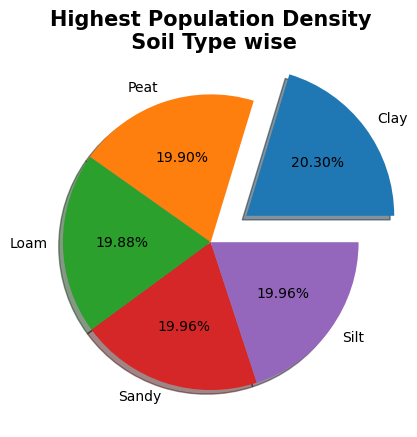

In [2294]:
flood_data.groupby('Soil Type')['River Discharge (m³/s)'].mean().plot(kind='pie',autopct='%.2f%%',labels=flood_data['Soil Type'].unique(),explode=[0.3,0,0,0,0],shadow=True)
plt.title("Highest Population Density\n Soil Type wise",fontweight='bold',fontsize=15) 
plt.ylabel("")
plt.show()

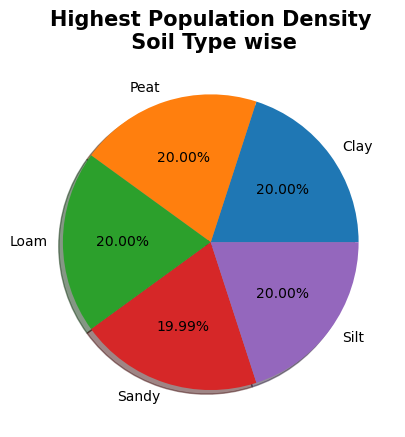

In [2314]:
flood_data.groupby('Soil Type')['River Discharge (m³/s)'].max().plot(kind='pie',autopct='%.2f%%',labels=flood_data['Soil Type'].unique(),explode=[0,0,0,0,0],shadow=True)
plt.title("Highest Population Density\n Soil Type wise",fontweight='bold',fontsize=15) 
plt.ylabel("")
plt.show()

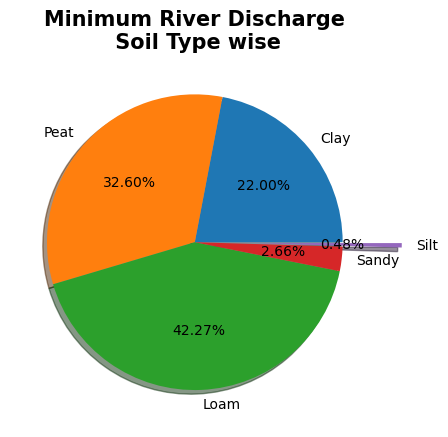

In [2326]:
flood_data.groupby('Soil Type')['River Discharge (m³/s)'].min().plot(kind='pie',autopct='%.2f%%',labels=flood_data['Soil Type'].unique(),explode=[0,0,0,0,0.4],shadow=True)
plt.title("Minimum River Discharge\n Soil Type wise",fontweight='bold',fontsize=15) 
plt.ylabel("")
plt.show()

In [1223]:
flood_data['Land Cover'].unique()

array(['Water Body', 'Forest', 'Agricultural', 'Desert', 'Urban'],
      dtype=object)

In [2312]:
flood_Yes=flood_data[(flood_data['Flood Occurred']==1) & (flood_data['Land Cover']=='Desert')]
desert=flood_yes.groupby(['Latitude','Land Cover'])['Rainfall (mm)'].max().sort_values(ascending=False).reset_index()
desert

,Latitude,Land Cover,Rainfall (mm)
0,32.840588,Agricultural,299.879515
1,27.387854,Agricultural,299.823176
2,20.734789,Agricultural,299.439035
3,35.871039,Agricultural,299.122463
4,27.606698,Agricultural,298.230685
...,...,...,...
1012,31.302712,Agricultural,1.069930
1013,19.922289,Agricultural,0.984339
1014,11.615218,Agricultural,0.825299
1015,16.818744,Agricultural,0.435095


<Figure size 1000x800 with 0 Axes>

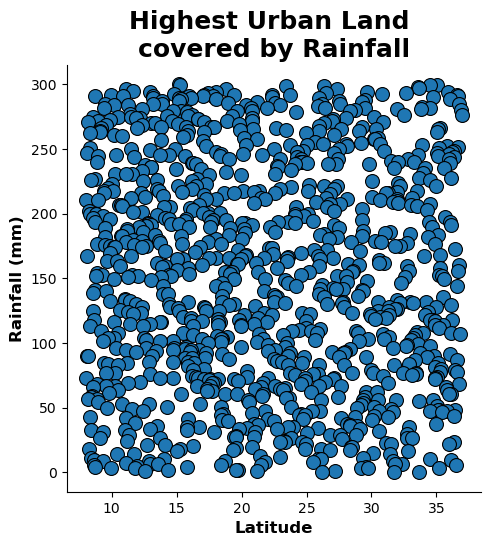

In [2230]:
plt.figure(figsize=(10,8))
sns.relplot(data=desert,x='Latitude',y='Rainfall (mm)', marker='o',kind='scatter',s=100,edgecolor='black')
plt.title("Highest Urban Land \ncovered by Rainfall",fontsize=18,fontweight='bold')
plt.xlabel("Latitude",fontsize=12,fontweight='bold')
plt.ylabel("Rainfall (mm)",fontsize=12,fontweight='bold')
plt.show()


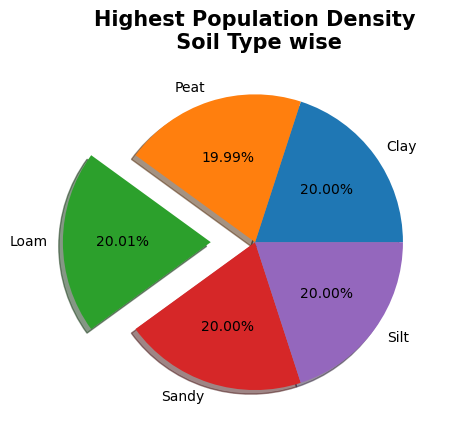

In [2333]:
#Highest Population density by Soil type?
flood_data.groupby('Soil Type')['Population Density'].max().plot(kind='pie',autopct='%.2f%%',labels=flood_data['Soil Type'].unique(),explode=[0,0,0.3,0,0],shadow=True)
plt.title("Highest Population Density\n Soil Type wise",fontweight='bold',fontsize=15) 
plt.ylabel("")
plt.show()

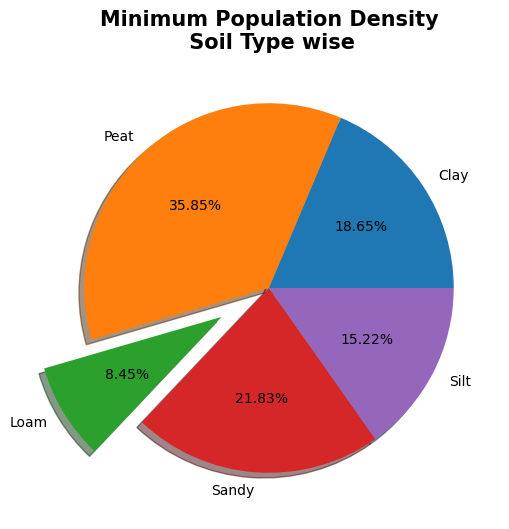

In [2335]:
#minimum Population density by Soil type?
plt.figure(figsize=(10,6))
flood_data.groupby('Soil Type')['Population Density'].min().plot(kind='pie',autopct='%.2f%%',labels=flood_data['Soil Type'].unique(),explode=[0,0,0.3,0,0],shadow=True)
plt.title("Minimum Population Density\n Soil Type wise",fontweight='bold',fontsize=15) 
plt.ylabel("")
plt.show()

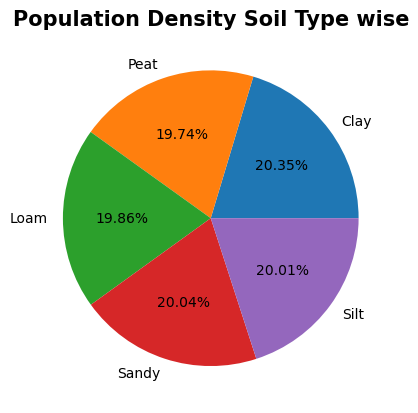

In [2338]:
#Average Population density by Soil type?
flood_data.groupby('Soil Type')['Population Density'].mean().plot(kind='pie',autopct='%.2f%%',labels=flood_data['Soil Type'].unique())
plt.title("Population Density Soil Type wise",fontweight='bold',fontsize=15) 
plt.ylabel("")
plt.show()

**Correlation in Heatmap**
----------------------------

In [1237]:
flood_data.columns

Index(['Latitude', 'Longitude', 'Rainfall (mm)', 'Temperature (°C)',
       'Humidity (%)', 'River Discharge (m³/s)', 'Water Level (m)',
       'Elevation (m)', 'Land Cover', 'Soil Type', 'Population Density',
       'Infrastructure', 'Historical Floods', 'Flood Occurred'],
      dtype='object')

In [2342]:
correlation=flood_data[['Latitude', 'Longitude', 'Rainfall (mm)', 'Temperature (°C)',
       'Humidity (%)', 'River Discharge (m³/s)', 'Water Level (m)',
       'Elevation (m)', 'Population Density',
       'Infrastructure', 'Historical Floods', 'Flood Occurred']].corr()
correlation

,Latitude,Longitude,Rainfall (mm),Temperature (°C),Humidity (%),River Discharge (m³/s),Water Level (m),Elevation (m),Population Density,Infrastructure,Historical Floods,Flood Occurred
Latitude,1.000000,-0.005125,-0.009346,0.006309,-0.007358,-0.016801,0.005722,0.007848,-0.003691,-0.011262,0.002121,-0.002908
Longitude,-0.005125,1.000000,-0.024219,-0.021281,-0.011014,0.005390,-0.009768,0.000446,0.012554,0.032261,0.004599,-0.015008
Rainfall (mm),-0.009346,-0.024219,1.000000,-0.004196,-0.007431,0.002065,-0.009397,0.000582,0.014651,-0.000801,-0.001691,-0.002170
Temperature (°C),0.006309,-0.021281,-0.004196,1.000000,0.011476,0.007498,-0.007165,0.006983,-0.004986,-0.018973,-0.008625,-0.015771
Humidity (%),-0.007358,-0.011014,-0.007431,0.011476,1.000000,-0.004298,0.005246,-0.014495,-0.018609,-0.012265,0.007100,0.027754
River Discharge (m³/s),-0.016801,0.005390,0.002065,0.007498,-0.004298,1.000000,-0.008686,0.004814,-0.000778,0.006485,-0.004734,-0.002115
Water Level (m),0.005722,-0.009768,-0.009397,-0.007165,0.005246,-0.008686,1.000000,-0.022645,0.009125,-0.006596,-0.027519,-0.005211
Elevation (m),0.007848,0.000446,0.000582,0.006983,-0.014495,0.004814,-0.022645,1.000000,-0.011155,0.002256,0.000706,-0.004331
Population Density,-0.003691,0.012554,0.014651,-0.004986,-0.018609,-0.000778,0.009125,-0.011155,1.000000,0.002787,-0.015036,-0.005007
Infrastructure,-0.011262,0.032261,-0.000801,-0.018973,-0.012265,0.006485,-0.006596,0.002256,0.002787,1.000000,-0.003390,-0.003846


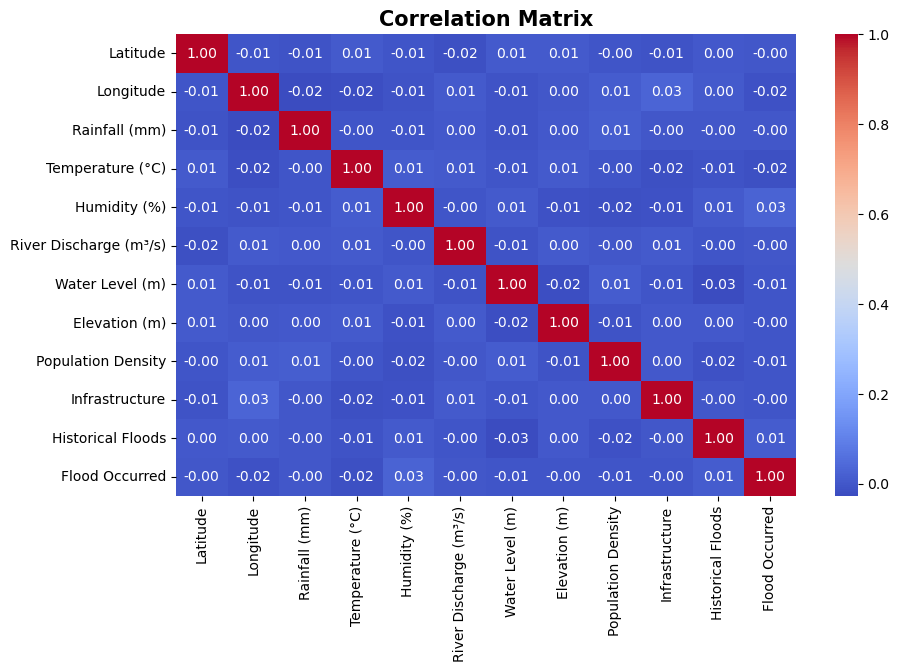

In [2348]:
plt.figure(figsize=(10,6))
sns.heatmap(data=correlation, annot=True, fmt='.2f', cmap='coolwarm')
plt.title("Correlation Matrix",fontweight='bold',fontsize=15)
plt.show()

In [2278]:
flood_data.groupby('Soil Type')['Population Density'].max()

Soil Type
Clay     9995.047582
Loam     9992.680742
Peat     9999.169530
Sandy    9997.014437
Silt     9997.532804
Name: Population Density, dtype: float64

**Label Encoding**
-------------------

In [1891]:
#Libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

In [1893]:
flood_data.sample()

,Latitude,Longitude,Rainfall (mm),Temperature (°C),Humidity (%),River Discharge (m³/s),Water Level (m),Elevation (m),Land Cover,Soil Type,Population Density,Infrastructure,Historical Floods,Flood Occurred
1243,32.498714,80.350188,105.703924,44.461452,97.738063,1694.166892,6.955523,5194.207464,Desert,Silt,2155.731442,1,1,1


In [1895]:
cat_cols=flood_data[['Land Cover', 'Soil Type']]
cat_cols

,Land Cover,Soil Type
0,Water Body,Clay
1,Forest,Peat
2,Agricultural,Loam
3,Desert,Sandy
4,Agricultural,Loam
...,...,...
9995,Agricultural,Clay
9996,Forest,Clay
9997,Desert,Clay
9998,Water Body,Sandy


In [1897]:
le=LabelEncoder()

In [1899]:
for i in cat_cols:
    flood_data[i]=le.fit_transform(flood_data[i])
#converted the categorical data into binary by using label encoding.     

In [1901]:
flood_data

,Latitude,Longitude,Rainfall (mm),Temperature (°C),Humidity (%),River Discharge (m³/s),Water Level (m),Elevation (m),Land Cover,Soil Type,Population Density,Infrastructure,Historical Floods,Flood Occurred
0,18.861663,78.835584,218.999493,34.144337,43.912963,4236.182888,7.415552,377.465433,4,0,7276.742184,1,0,1
1,35.570715,77.654451,55.353599,28.778774,27.585422,2472.585219,8.811019,7330.608875,2,2,6897.736956,0,1,0
2,29.227824,73.108463,103.991908,43.934956,30.108738,977.328053,4.631799,2205.873488,0,1,4361.518494,1,1,1
3,25.361096,85.610733,198.984191,21.569354,34.453690,3683.208933,2.891787,2512.277800,1,3,6163.069701,1,1,0
4,12.524541,81.822101,144.626803,32.635692,36.292267,2093.390678,3.188466,2001.818223,0,1,6167.964591,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,32.872024,93.434120,285.682635,37.621017,69.795616,4830.703665,5.943965,2850.197900,0,0,6943.559433,0,0,0
9996,34.027756,69.357605,224.347263,37.935808,38.095486,1866.199787,9.466158,3314.692947,2,0,3011.997459,1,0,0
9997,35.454530,76.807256,5.836759,23.087083,79.919607,1523.374305,9.209185,3377.296962,1,0,7149.938303,1,0,1
9998,19.527152,80.856280,120.301453,28.029593,61.680873,2036.812638,2.004644,1146.986151,4,3,906.031452,1,0,1


In [1903]:
x=flood_data.drop('Flood Occurred',axis=1)
x

,Latitude,Longitude,Rainfall (mm),Temperature (°C),Humidity (%),River Discharge (m³/s),Water Level (m),Elevation (m),Land Cover,Soil Type,Population Density,Infrastructure,Historical Floods
0,18.861663,78.835584,218.999493,34.144337,43.912963,4236.182888,7.415552,377.465433,4,0,7276.742184,1,0
1,35.570715,77.654451,55.353599,28.778774,27.585422,2472.585219,8.811019,7330.608875,2,2,6897.736956,0,1
2,29.227824,73.108463,103.991908,43.934956,30.108738,977.328053,4.631799,2205.873488,0,1,4361.518494,1,1
3,25.361096,85.610733,198.984191,21.569354,34.453690,3683.208933,2.891787,2512.277800,1,3,6163.069701,1,1
4,12.524541,81.822101,144.626803,32.635692,36.292267,2093.390678,3.188466,2001.818223,0,1,6167.964591,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,32.872024,93.434120,285.682635,37.621017,69.795616,4830.703665,5.943965,2850.197900,0,0,6943.559433,0,0
9996,34.027756,69.357605,224.347263,37.935808,38.095486,1866.199787,9.466158,3314.692947,2,0,3011.997459,1,0
9997,35.454530,76.807256,5.836759,23.087083,79.919607,1523.374305,9.209185,3377.296962,1,0,7149.938303,1,0
9998,19.527152,80.856280,120.301453,28.029593,61.680873,2036.812638,2.004644,1146.986151,4,3,906.031452,1,0


In [1905]:
y=flood_data['Flood Occurred']
y

0       1
1       0
2       1
3       0
4       0
       ..
9995    0
9996    0
9997    1
9998    1
9999    1
Name: Flood Occurred, Length: 10000, dtype: int64

**Split Data**
------------

In [1908]:
xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

In [1910]:
len(xtrain),len(xtest),len(ytrain),len(xtest)

(8000, 2000, 8000, 2000)


------------------

In [2063]:
# Algorithm libraries 
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

In [2377]:
lr=LogisticRegression(C=1.5)
lr.fit(xtrain,ytrain)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.5
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [2379]:
ypred=lr.predict(xtest)
ypred

array([0, 0, 1, ..., 1, 0, 0], dtype=int64)

In [2381]:
print(accuracy_score(ypred,ytest))

0.5075


In [2383]:
print(confusion_matrix(ypred,ytest))

[[401 397]
 [588 614]]


In [2385]:
print(f'Accuracy Score is:\n {accuracy_score(ypred,ytest)}')
print('---------------------------------------------')
print(f'Confusion Matrix is:\n {confusion_matrix(ypred,ytest)}')
print('---------------------------------------------')
print(f'Classification Report is:\n{classification_report(ypred,ytest)}')

Accuracy Score is:
 0.5075
---------------------------------------------
Confusion Matrix is:
 [[401 397]
 [588 614]]
---------------------------------------------
Classification Report is:
              precision    recall  f1-score   support

           0       0.41      0.50      0.45       798
           1       0.61      0.51      0.55      1202

    accuracy                           0.51      2000
   macro avg       0.51      0.51      0.50      2000
weighted avg       0.53      0.51      0.51      2000



**Decision Tree Classifier**
-----------------------------

In [2076]:
clf=DecisionTreeClassifier(criterion='entropy',random_state=42,max_depth=9)

In [2078]:
clf.fit(xtrain,ytrain)

,criterion,'entropy'
,splitter,'best'
,max_depth,9
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [2080]:
ypred=clf.predict(xtest)
ypred

array([0, 1, 0, ..., 0, 0, 0], dtype=int64)

In [2082]:
print(f'Accuracy Rate with Max Depth 9: {accuracy_score(ypred,ytest)}')

Accuracy Rate with Max Depth 9: 0.5135


In [2084]:
#checked by best max depth through Loop
train_score =[]
test_score =[]
for i in range(1,20):
    clf = DecisionTreeClassifier(max_depth=i,criterion='entropy',random_state=42)
    clf.fit(xtrain,ytrain)
    train_acc = clf.score(xtrain,ytrain)
    test_acc = clf.score(xtest,ytest)
    train_score.append(train_acc)
    test_score.append(test_acc)
    print(f"Depth {i} Training Acc = {train_acc}   Testing Acc = {test_acc}")

Depth 1 Training Acc = 0.50575   Testing Acc = 0.5055
Depth 2 Training Acc = 0.509875   Testing Acc = 0.5075
Depth 3 Training Acc = 0.52225   Testing Acc = 0.5125
Depth 4 Training Acc = 0.524125   Testing Acc = 0.5125
Depth 5 Training Acc = 0.525875   Testing Acc = 0.508
Depth 6 Training Acc = 0.535375   Testing Acc = 0.51
Depth 7 Training Acc = 0.53925   Testing Acc = 0.51
Depth 8 Training Acc = 0.549875   Testing Acc = 0.517
Depth 9 Training Acc = 0.558375   Testing Acc = 0.5135
Depth 10 Training Acc = 0.56975   Testing Acc = 0.5015
Depth 11 Training Acc = 0.58625   Testing Acc = 0.4975
Depth 12 Training Acc = 0.60125   Testing Acc = 0.5
Depth 13 Training Acc = 0.615125   Testing Acc = 0.495
Depth 14 Training Acc = 0.6295   Testing Acc = 0.498
Depth 15 Training Acc = 0.648625   Testing Acc = 0.5035
Depth 16 Training Acc = 0.66625   Testing Acc = 0.515
Depth 17 Training Acc = 0.687875   Testing Acc = 0.5075
Depth 18 Training Acc = 0.7105   Testing Acc = 0.513
Depth 19 Training Acc = 0

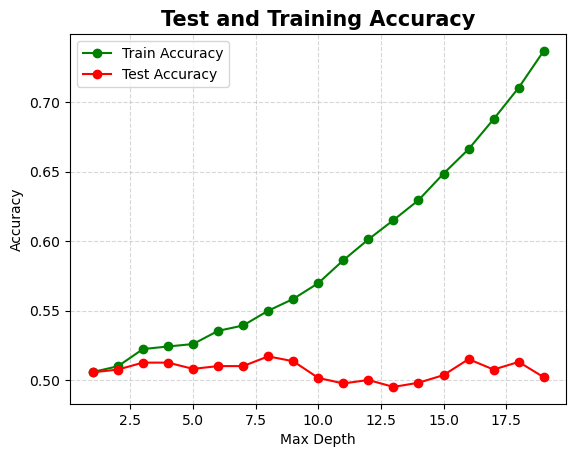

In [2113]:
plt.plot(range(1,20),train_score,label='Train Accuracy',marker='o',color='green')
plt.plot(range(1,20),test_score,label='Test Accuracy',marker='o',color='red')
plt.xlabel('Max Depth')
plt.ylabel('Accuracy')
plt.title("Test and Training Accuracy",fontsize=15,fontweight='bold')
plt.legend()
plt.grid(linestyle='--',alpha=0.5)
plt.show()

**Bagging technique Random Forest**
---------------------------------

In [2087]:
bag_model = BaggingClassifier(estimator=DecisionTreeClassifier(),
                             n_estimators=15,
                             random_state=42,
                             bootstrap=True)

In [2088]:
bag_model.fit(xtrain,ytrain)

,estimator,DecisionTreeClassifier()
,n_estimators,15
,max_samples,1.0
,max_features,1.0
,bootstrap,True
,bootstrap_features,False
,oob_score,False
,warm_start,False
,n_jobs,None
,random_state,42
,verbose,0


In [2089]:
ypredict=bag_model.predict(xtest)
ypredict

array([0, 1, 1, ..., 0, 0, 0], dtype=int64)

In [2093]:
accuracy_score(ypredict,ytest)

0.5025

In [2094]:
print(f'Accuracy Score is:\n {accuracy_score(ypred,ytest)}')
print('---------------------------------------------')
print(f'Confusion Matrix is:\n {confusion_matrix(ypred,ytest)}')
print('---------------------------------------------')
print(f'Classification Report is:\n{classification_report(ypred,ytest)}')

Accuracy Score is:
 0.5135
---------------------------------------------
Confusion Matrix is:
 [[628 612]
 [361 399]]
---------------------------------------------
Classification Report is:
              precision    recall  f1-score   support

           0       0.63      0.51      0.56      1240
           1       0.39      0.53      0.45       760

    accuracy                           0.51      2000
   macro avg       0.51      0.52      0.51      2000
weighted avg       0.54      0.51      0.52      2000



**XGBOOST Classifier**
-----------


In [2423]:
xgb=XGBClassifier(learning_rate=0.2)
xgb.fit(xtrain,ytrain)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [2425]:
ypred=xgb.predict(xtest)
ypred

array([0, 0, 1, ..., 1, 0, 0])

In [2427]:
print(f'Accuracy Score is:\n {accuracy_score(ypred,ytest)}')
print('---------------------------------------------')
print(f'Confusion Matrix is:\n {confusion_matrix(ypred,ytest)}')
print('---------------------------------------------')
print(f'Classification Report is:\n{classification_report(ypred,ytest)}')

Accuracy Score is:
 0.5135
---------------------------------------------
Confusion Matrix is:
 [[493 477]
 [496 534]]
---------------------------------------------
Classification Report is:
              precision    recall  f1-score   support

           0       0.50      0.51      0.50       970
           1       0.53      0.52      0.52      1030

    accuracy                           0.51      2000
   macro avg       0.51      0.51      0.51      2000
weighted avg       0.51      0.51      0.51      2000



**Observation**
I have used four Algorithms for my Flood risk dataset.
From all four algorithms my best Accuracy Score is 51 From Decision Tree,random Forest and XGBoost Classifier Algorithm Although 
the Logistic regression Algorithm also gave me 50 Accuracy.My data has 10,000 rows and it is clean with No outlier thats why no skewness. As my model accuracy is 51% ,I checked the Training Acc = 0.558375  and Testing Acc = 0.5135 in Decision Tree which clearly depicts the model has learnt its best and test score is correct ,which means the model is neither overfit neither underfit.
So as the data has almost no correlation in between which i checked through correlation matrix could be the reason of this accuracy rate. 


In [2396]:
# flood_data